# Q vs Pressure
Lorentzian fits to the ~29 Hz mechanical resonance from the 2025-03-17 pressure sweep.
Data: `Dropbox/Microspheres/data/th228_sail/20250317/transfer_func_data_noise_0.086Hz_20.000V_*mbar.npz`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import scipy.signal as sp
from scipy.optimize import curve_fit

In [2]:
DATA_DIR = "/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250317/"

CHANNEL_LIST  = ['x', 'y', 'Sum', 'Drive']
FIT_CHANNEL   = 'y'
FIT_RANGE     = [23.0, 33.0]          # Hz — wide enough to cover peak shift across pressures
NOISE_FREQS   = []                     # no known pump noise lines in this dataset
BAD_PRESSURES = []

In [3]:
def make_psd(files, nperseg=2**14):
    """Average Welch PSDs across all segments in a list of .npz files."""
    psd_dict = {ch: None for ch in CHANNEL_LIST}
    n = 0
    freqs_out = None
    for fpath in files:
        data = np.load(fpath)
        fs = float(data['Fs'])
        for seg in data['data']:
            if np.abs(np.median(seg[:, 1])) > 3:
                continue
            for ci, ch in enumerate(CHANNEL_LIST):
                freqs_out, cpsd = sp.welch(seg[:, ci], fs=fs, nperseg=nperseg)
                psd_dict[ch] = cpsd if psd_dict[ch] is None else psd_dict[ch] + cpsd
            n += 1
    if n == 0:
        return None, None
    for ch in CHANNEL_LIST:
        psd_dict[ch] /= n
    return psd_dict, freqs_out


def lorentzian_psd(f, A, f0, gamma):
    w  = 2 * np.pi * f
    w0 = 2 * np.pi * f0
    g  = 2 * np.pi * gamma
    return A / ((w**2 - w0**2)**2 + w**2 * g**2)


def fit_lorentzian(psd_dict, freqs, f0_guess=29.0, noise_freqs=NOISE_FREQS, ch=FIT_CHANNEL):
    """Fit Lorentzian in a ±2 Hz window around f0_guess. Returns (bp, bcov) or (None, None)."""
    fit_range = [f0_guess - 2.0, f0_guess + 2.0]
    bad = np.zeros(len(freqs), dtype=bool)
    for lo, hi in noise_freqs:
        bad |= (freqs > lo) & (freqs < hi)
    mask = (freqs > fit_range[0]) & (freqs < fit_range[1]) & ~bad

    ff = freqs[mask]
    pp = psd_dict[ch][mask]
    if len(ff) < 5:
        return None, None

    try:
        bp, bcov = curve_fit(lorentzian_psd, ff, pp,
                             p0=[1e3, f0_guess, 1.0],
                             sigma=pp,
                             bounds=([0, f0_guess - 2, 0.01], [np.inf, f0_guess + 2, 10.0]),
                             maxfev=5000)
    except RuntimeError:
        return None, None
    return bp, bcov

In [4]:
# Load and sort files — exclude low-drive (0.002V) files which have too little SNR
pressure_files = sorted(
    [f for f in glob(DATA_DIR + "transfer_func_data_noise_*mbar.npz")
     if '0.002V' not in f],
    key=lambda f: float(f.split('_')[-1].replace('mbar.npz', ''))
)
pressure_list = np.array([float(f.split('_')[-1].replace('mbar.npz', '')) for f in pressure_files])

print(f"Found {len(pressure_files)} files")
print(f"Pressure range: {pressure_list.min():.2e} – {pressure_list.max():.2e} mbar")

Found 45 files
Pressure range: 5.57e-07 – 2.26e+00 mbar


In [5]:
Q_values    = []
Q_errors    = []
Q_pressures = []
Q_flags     = []

last_f0 = 29.0   # warm-start: track f0 from fit to fit

for p, fpath in zip(pressure_list, pressure_files):
    if p in BAD_PRESSURES:
        continue

    nperseg = 2**14 if p < 0.1 else 2**13
    psd_dict, freqs = make_psd([fpath], nperseg=nperseg)
    if psd_dict is None:
        continue

    bp, bcov = fit_lorentzian(psd_dict, freqs, f0_guess=last_f0)
    if bp is None:
        print(f"Fit failed at {p:.2e} mbar")
        continue

    f0    = bp[1]
    gamma = abs(bp[2])
    last_f0 = f0   # update warm-start

    Q = f0 / gamma

    sigma_f0    = np.sqrt(bcov[1, 1])
    sigma_gamma = np.sqrt(abs(bcov[2, 2]))
    sigma_Q     = Q * np.sqrt((sigma_f0 / f0)**2 + (sigma_gamma / gamma)**2)

    flag = "suspect" if (Q > 150 or Q < 10 or gamma < 0.05 or gamma > 3.0) else "good"

    Q_values.append(Q)
    Q_errors.append(sigma_Q)
    Q_pressures.append(p)
    Q_flags.append(flag)

    print(f"{p:.2e} mbar  f0={f0:.2f} Hz  gamma={gamma:.3f} Hz  Q={Q:.1f} ± {sigma_Q:.1f}  [{flag}]")

Q_values    = np.array(Q_values)
Q_errors    = np.array(Q_errors)
Q_pressures = np.array(Q_pressures)
Q_flags     = np.array(Q_flags)

5.57e-07 mbar  f0=28.80 Hz  gamma=0.372 Hz  Q=77.4 ± 7.1  [good]
1.01e-06 mbar  f0=28.71 Hz  gamma=0.307 Hz  Q=93.5 ± 10.1  [good]
3.50e-06 mbar  f0=28.83 Hz  gamma=0.289 Hz  Q=99.7 ± 10.2  [good]
1.33e-05 mbar  f0=28.80 Hz  gamma=0.367 Hz  Q=78.6 ± 8.8  [good]
5.80e-05 mbar  f0=28.78 Hz  gamma=0.332 Hz  Q=86.8 ± 15.4  [good]
9.21e-05 mbar  f0=28.77 Hz  gamma=0.378 Hz  Q=76.0 ± 6.9  [good]
1.09e-04 mbar  f0=28.73 Hz  gamma=0.324 Hz  Q=88.7 ± 13.2  [good]
1.25e-04 mbar  f0=28.75 Hz  gamma=0.337 Hz  Q=85.2 ± 6.8  [good]
1.68e-04 mbar  f0=28.74 Hz  gamma=0.373 Hz  Q=77.2 ± 5.2  [good]
2.29e-04 mbar  f0=28.71 Hz  gamma=0.354 Hz  Q=81.1 ± 6.7  [good]
3.22e-04 mbar  f0=28.77 Hz  gamma=0.309 Hz  Q=93.2 ± 14.3  [good]
2.10e-03 mbar  f0=28.60 Hz  gamma=0.288 Hz  Q=99.3 ± 10.7  [good]
2.64e-03 mbar  f0=28.61 Hz  gamma=0.294 Hz  Q=97.3 ± 11.8  [good]
4.78e-03 mbar  f0=28.51 Hz  gamma=0.380 Hz  Q=75.0 ± 8.0  [good]
5.34e-03 mbar  f0=28.44 Hz  gamma=0.358 Hz  Q=79.5 ± 11.7  [good]
6.04e-03 mbar  f0

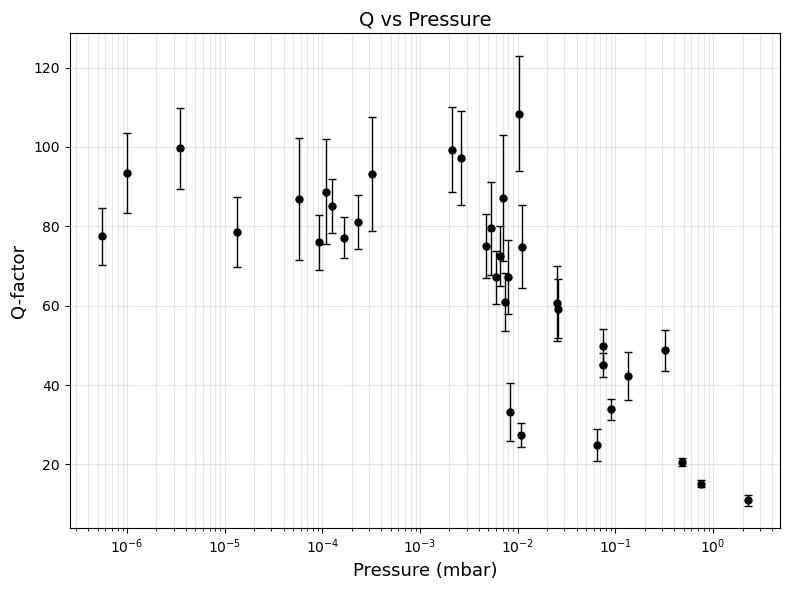

In [6]:
good = Q_flags == "good"

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(Q_pressures[good], Q_values[good], yerr=Q_errors[good],
            fmt='o', color='black', capsize=3, markersize=5, elinewidth=1)

ax.set_xscale('log')
ax.set_xlabel('Pressure (mbar)', fontsize=13)
ax.set_ylabel('Q-factor', fontsize=13)
ax.set_title('Q vs Pressure', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('q_vs_pressure.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

Q0 (plateau mean, 7 bins) = 85.9 ± 3.2
Pc = 9.55e+00 ± 3.79e-01 mbar


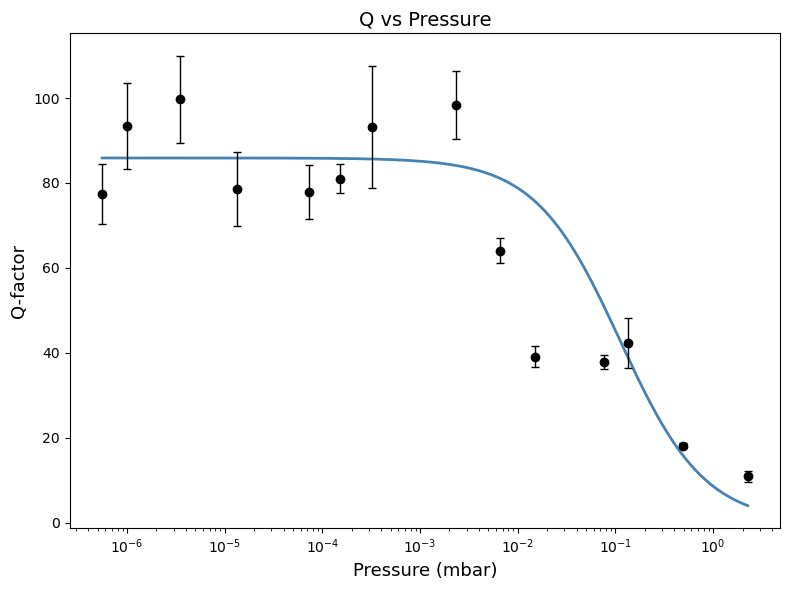

In [14]:
from scipy.optimize import curve_fit as cf2

# --- log-bin the good points ---
good = Q_flags == "good"
p_good = Q_pressures[good]
q_good = Q_values[good]
e_good = Q_errors[good]

log_edges = np.arange(np.floor(np.log10(p_good.min())),
                      np.ceil(np.log10(p_good.max())) + 0.5, 0.5)
bin_p, bin_q, bin_e = [], [], []
for lo, hi in zip(log_edges[:-1], log_edges[1:]):
    mask = (np.log10(p_good) >= lo) & (np.log10(p_good) < hi)
    if mask.sum() == 0:
        continue
    w = 1.0 / e_good[mask]**2
    bin_q.append(np.sum(w * q_good[mask]) / np.sum(w))
    bin_p.append(np.exp(np.mean(np.log(p_good[mask]))))
    bin_e.append(1.0 / np.sqrt(np.sum(w)))

bin_p = np.array(bin_p); bin_q = np.array(bin_q); bin_e = np.array(bin_e)

# --- Q0: unweighted mean of plateau bins (P < 1e-3 mbar) ---
plateau = bin_p < 1e-3
Q0_fit = np.mean(bin_q[plateau])
Q0_err = np.std(bin_q[plateau]) / np.sqrt(plateau.sum())
print(f"Q0 (plateau mean, {plateau.sum()} bins) = {Q0_fit:.1f} ± {Q0_err:.1f}")

# --- Pc: fit only the clean rolloff (P > 0.05 mbar) ---
rolloff = bin_p > 0.05
def q_model_Pc(P, Pc):
    return Q0_fit / (1 + Q0_fit * P / Pc)

bp, bcov = cf2(q_model_Pc, bin_p[rolloff], bin_q[rolloff],
               p0=[0.05], sigma=bin_e[rolloff], absolute_sigma=True)
Pc_fit = bp[0]; Pc_err = np.sqrt(bcov[0, 0])
print(f"Pc = {Pc_fit:.2e} ± {Pc_err:.2e} mbar")

p_smooth = np.logspace(np.log10(p_good.min()), np.log10(p_good.max()), 300)
q_smooth = Q0_fit / (1 + Q0_fit * p_smooth / Pc_fit)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(bin_p, bin_q, yerr=bin_e,
            fmt='o', color='black', capsize=3, markersize=6, elinewidth=1,
            label='data (binned)', zorder=3)
ax.plot(p_smooth, q_smooth, color='steelblue', linewidth=2,
        label=fr'$Q_0={Q0_fit:.0f} \pm {Q0_err:.0f}$,  $P_c={Pc_fit:.2e}$ mbar')

ax.set_xscale('log')
ax.set_xlabel('Pressure (mbar)', fontsize=13)
ax.set_ylabel('Q-factor', fontsize=13)
ax.set_title('Q vs Pressure', fontsize=14)
# ax.legend(fontsize=11)
# ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('q_vs_pressure_fit.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()